# GraphPlanner Execution

This notebook loads an existing scenario bundle, builds the candidate graph, computes edge metrics with the geo service, runs RPL, and saves the result. Scenario creation belongs in `scenario_builder.ipynb`.

In [1]:
from pathlib import Path
import sys
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from cisei_lib.io.async_geo_service_pool import AsyncGeoServicePool
from cisei_lib.planners import GraphPlanner, PlanningScenario
import cisei_lib.planners.planner_reports as reports

SCENARIO_DIR = NOTEBOOK_DIR / "scenario_exports"
RESULT_DIR = NOTEBOOK_DIR / "planning_results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

SINGLE_INTERFACE = SCENARIO_DIR / "graph_planner_single_interface.toml"
TWO_INTERFACE = SCENARIO_DIR / "graph_planner_two_interface.toml"
ANTENNA_FUNCTION_TEST = SCENARIO_DIR / "graph_planner_antenna_function_test.toml"

GEO_BASE_URL = "http://planning-service:8080"
GEO_USER_PREFIX = "graph-planner-demo"
GEO_POOL_SIZE = 2

## 1. Load Scenario

Choose one exported TOML bundle. The companion `.nodes.csv` is loaded automatically when the TOML contains an `[instances]` section.

In [2]:
SCENARIO_PATH = SINGLE_INTERFACE
# SCENARIO_PATH = TWO_INTERFACE
SCENARIO_PATH = ANTENNA_FUNCTION_TEST

scenario = PlanningScenario.from_toml(SCENARIO_PATH)
planner = GraphPlanner(scenario)

print("scenario:", SCENARIO_PATH.name)
print("validation errors:", scenario.validate())
reports.node_table(planner, kind="rpl")

scenario: graph_planner_antenna_function_test.toml
validation errors: []


,node_id,site_id,device_id,tech,freq_mhz,tx_power_dbm,antenna_id,mount_height_m,max_links,interface_can_relay,connected,rpl_relay,rank,x,y
0,torre:d0:i0,torre,torre:d0,antenna_test,915.0,30.0,tower_pctel_boa9028,100.0,inf,False,True,True,0.0,671574.031187,7.187057e+06
1,guaira:d0:i0,guaira,guaira:d0,antenna_test,915.0,20.0,leaf_pctel_boa9028,7.0,inf,False,False,False,inf,674430.332863,7.186550e+06


## 2. Build Candidate Graph

The candidate graph is created from the TOML connectivity rules and any manually specified candidate edges.

In [3]:
candidate_edges = planner.build_candidate_edges_from_rules()
candidate_graph = planner.candidate_graph()

print("candidate nodes:", candidate_graph.number_of_nodes())
print("candidate edges:", candidate_graph.number_of_edges())
reports.edge_table(planner, kind="candidate")

candidate nodes: 2
candidate edges: 1


,src,dst,kind,rule,src_site,dst_site,src_tech,dst_tech,src_freq_mhz,dst_freq_mhz,src_max_links,dst_max_links,src_mount_height_m,dst_mount_height_m
0,torre:d0:i0,guaira:d0:i0,rf,connectivity_0,torre,guaira,antenna_test,antenna_test,915.0,915.0,inf,inf,100.0,7.0


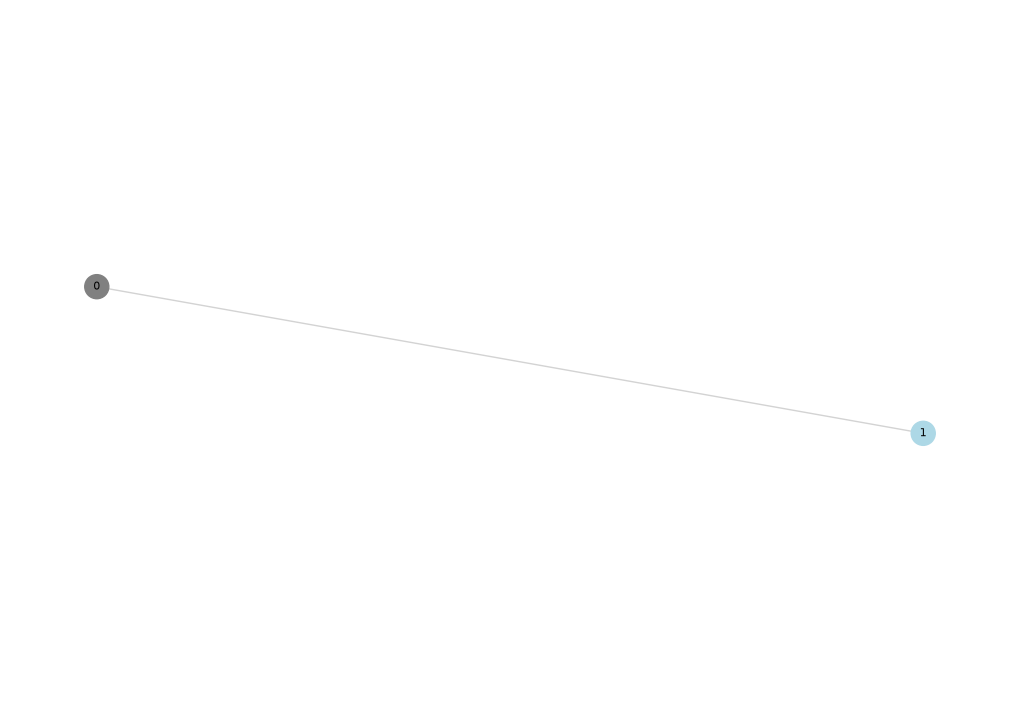

In [4]:
reports.draw_network_graph(
    candidate_graph,
    label_mode="index",
    spread_same_position=True,
)

## 3. Compute Metrics

Keep one `AsyncGeoServicePool` instance while experimenting so the feature service can reuse prepared profiles and cache repeated links.

In [5]:
geo = AsyncGeoServicePool(
    base_url=GEO_BASE_URL,
    user_prefix=GEO_USER_PREFIX,
    pool_size=GEO_POOL_SIZE,
    timeout=120,
)

await geo.start()

APIResult(kind='json')
APIResult(kind='json')


In [6]:
edge_metrics = await planner.compute_edge_metrics(
    geo,
    manage_geo=False,
)

reports.edge_table(planner, kind="metric")

,src,dst,kind,rule,src_site,dst_site,src_tech,dst_tech,src_freq_mhz,dst_freq_mhz,src_max_links,dst_max_links,src_mount_height_m,dst_mount_height_m,metric
0,torre:d0:i0,guaira:d0:i0,rf,connectivity_0,torre,guaira,antenna_test,antenna_test,915.0,915.0,inf,inf,100.0,7.0,1.0


## Optional: Inspect Antenna Gains

This cell reads the metric records already stored in memory by `compute_edge_metrics`. It does not call the geo service again.


In [7]:
reports.antenna_gain_table(planner)


,src,dst,dist_m,src_site,dst_site,src_tech,dst_tech,src_freq_mhz,dst_freq_mhz,tx_power_dbm,...,tx_height_m,tx_gain_dbi,rx_antenna_id,rx_model_id,rx_antenna_name,rx_type,rx_height_m,rx_gain_dbi,total_ant_gain_dbi,metric
0,torre:d0:i0,guaira:d0:i0,2901.0,torre,guaira,antenna_test,antenna_test,915.0,915.0,30.0,...,100.0,7.252519,leaf_pctel_boa9028,pctel_boa9028,Library-backed PCTEL BOA9028 at the field site,omni,7.0,7.252519,14.505037,1.0


## 4. Run RPL And Save Result

In [8]:
planner.run_rpl()

reports.edge_table(planner, kind="result")

,src,dst,kind,rule,src_site,dst_site,src_tech,dst_tech,src_freq_mhz,dst_freq_mhz,src_max_links,dst_max_links,src_mount_height_m,dst_mount_height_m,metric
0,torre:d0:i0,guaira:d0:i0,rf,connectivity_0,torre,guaira,antenna_test,antenna_test,915.0,915.0,inf,inf,100.0,7.0,1.0


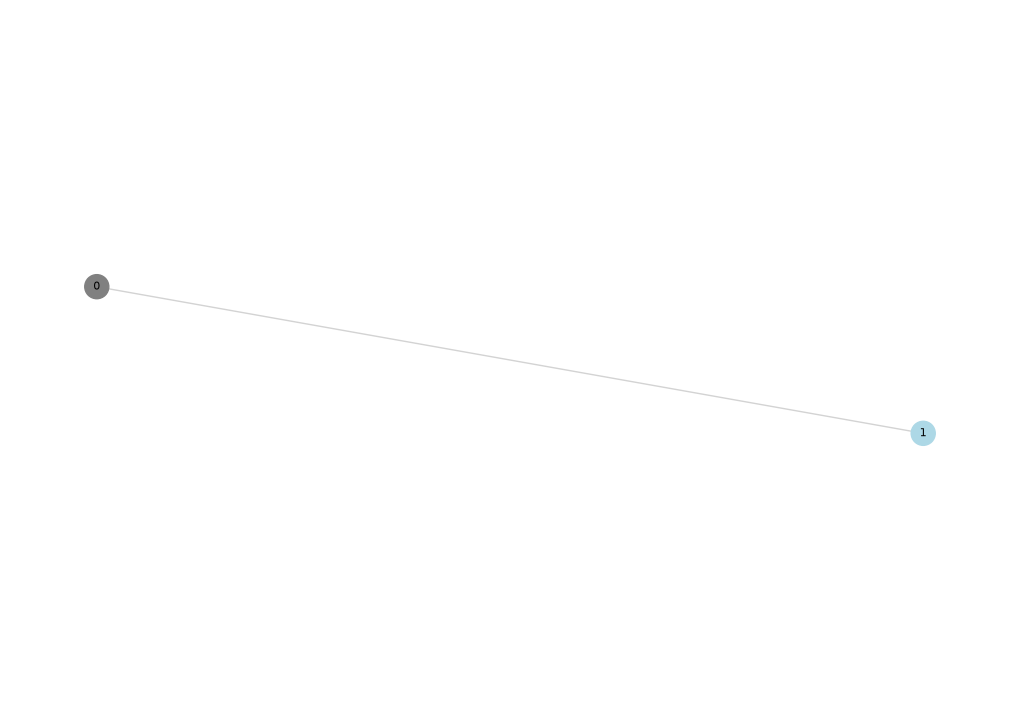

In [9]:
reports.draw_network_graph(
    planner.rpl.G_res,
    label_mode="index",
    spread_same_position=True,
)

In [10]:
result_path = RESULT_DIR / f"{SCENARIO_PATH.stem}.result.json"
planner.save_results(result_path, include_features=True)
result_path

PosixPath('/workspaces/network_service/tests/jupyter/planning_results/graph_planner_antenna_function_test.result.json')

## 5. Optional Pool Cleanup

Run this cell when you are done with this notebook session.

In [ ]:
await geo.close()